In [32]:
import polars as pl
import matplotlib.pyplot as plt

from spells import summon, ColSpec, ColType, ColName
from deq.plot import line_plot


In [20]:

set_code = "TDM"
filter_spec = {
    '$and': [
        {'player_cohort': 'Top'},
        {'pack_num': 1},
        {'op': '<', 'lhs': 'pick_num', 'rhs': 14}
    ]
}

ext = {
    'pick_rate_logit': ColSpec(
        col_type=ColType.AGG,
        expr=pl.when(pl.col(ColName.NUM_TAKEN)>0).then(
            (pl.col(ColName.NUM_TAKEN) / (pl.col(ColName.PACK_CARD) - pl.col(ColName.NUM_TAKEN))).log() - pl.lit(1.0/7.0).log()
        ).otherwise(None)
    ),
}

df = summon(
    'TDM',
    ['pick_rate_logit'],
    group_by=['name', 'pick_num'],
    filter_spec = filter_spec,
    extensions=ext
)

means_df = summon(
    "TDM",
    ["ata", "pick_rate_logit"],
    filter_spec=filter_spec,
    extensions=ext
)

In [44]:

cards = [
    "Descendant of Storms",
    "Barrensteppe Siege",
    "Undergrowth Leopard",
    "Marang River Regent",
    "Qarsi Revenant",
    "Ambling Stormshell"
]


card_df = df.filter(~pl.col('pick_rate_logit').is_null()).filter(pl.col('name').is_in(cards))
card_means = means_df.filter(pl.col('name').is_in(cards))

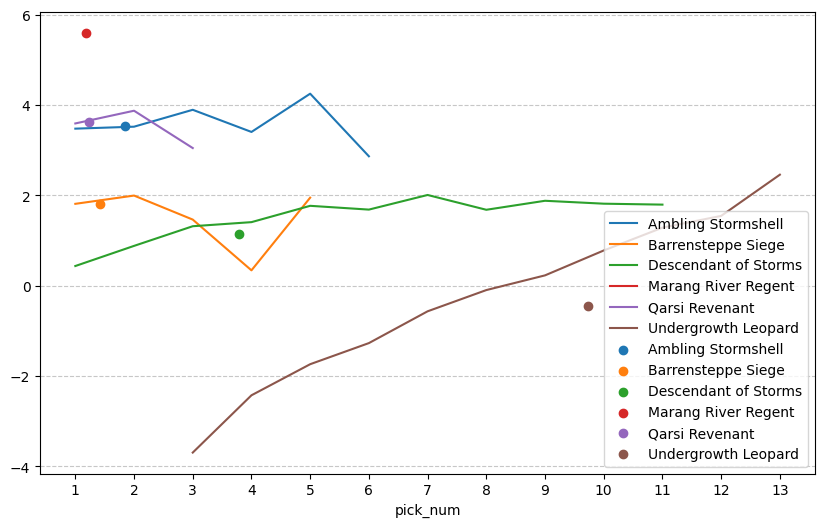

In [45]:
ax = line_plot(card_df.sort('pick_num').pivot(on="name", index="pick_num", values="pick_rate_logit"), return_ax=True)

for row in card_means.to_dicts()[0:10]:
    ax.scatter(row['ata'], row['pick_rate_logit'], label=row['name'])
ax.legend()

{'name': 'Abzan Devotee', 'ata': 9.378228782287822, 'pick_rate_logit': -0.6107735207589875}
{'name': 'Abzan Monument', 'ata': 8.121783876500858, 'pick_rate_logit': -0.1643550276940009}
{'name': 'Adorned Crocodile', 'ata': 11.41281512605042, 'pick_rate_logit': -1.0131821120842557}
{'name': 'Aegis Sculptor', 'ata': 7.901069518716578, 'pick_rate_logit': -0.521917433903548}
{'name': 'Agent of Kotis', 'ata': 10.733235077376566, 'pick_rate_logit': -0.5665547962124373}
{'name': 'Aggressive Negotiations', 'ata': 10.334648257725181, 'pick_rate_logit': -0.4903871223244032}
{'name': 'Ainok Wayfarer', 'ata': 6.932150313152401, 'pick_rate_logit': 0.6934454654242004}
{'name': "Alchemist's Assistant", 'ata': 6.463730569948186, 'pick_rate_logit': -0.3023774140538964}
{'name': "Alesha's Legacy", 'ata': 11.53781512605042, 'pick_rate_logit': -1.2951272476157398}
{'name': 'All-Out Assault', 'ata': 1.2994011976047903, 'pick_rate_logit': 3.112660242890641}
